# Importación de Librerías

In [1]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, TargetEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Carga del Dataset

In [2]:
# Cargar los conjuntos de datos en su ruta correcta
df_train = pd.read_csv("dataset/processed/dataset_entrenamiento.csv")
df_test = pd.read_csv("dataset/processed/dataset_prueba.csv")

# Definición de Variables Predictoras y Objetivo

In [3]:
# Lista de variables predictoras seleccionadas
features = [
    "Mercado",
    "Subsector",
    "Producto",
    "Variedad / Tipo",
    "Calidad",
    "Origen",
    "Volumen_Limpio",
    "weight_kg",
    "Mes",
    "Dia_Semana",
    "Estacion"
]

target = "Precio_Promedio_Por_Kilo"

# Separación de X e y

In [4]:
X_train = df_train[features]
y_train = df_train[target]
X_test = df_test[features]
y_test = df_test[target]

# Validación de Partición

In [5]:
# Imprimimos las dimensiones para verificar que la carga fue exitosa
print(f"Dimensiones de X_train: {X_train.shape} | X_test: {X_test.shape}")

Dimensiones de X_train: (144018, 11) | X_test: (27374, 11)


# Identificación de Variables para Preprocesamiento

In [6]:
# Categóricas de baja cardinalidad
cat_baja = ["Subsector", "Estacion"]

# Categóricas de alta cardinalidad
cat_alta = ["Mercado", "Producto", "Variedad / Tipo", "Calidad", "Origen"]

# Variables numéricas
numeric_features = [
    "Volumen_Limpio",
    "weight_kg",
    "Mes",
    "Dia_Semana"
]

# Creación de Transformador de Columnas

In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat_baja",
            OneHotEncoder(handle_unknown="ignore"),
            cat_baja
        ),
        (
            "cat_alta",
            TargetEncoder(smooth="auto", cv=5, random_state=42),
            cat_alta
        ),
        (
            "num",
            "passthrough",
            numeric_features
        )
    ]
)

# Definición del Modelo

In [8]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

# Construcción del Pipeline

In [9]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf_model)
])

# Entrenamiento y Evaluación del Modelo

In [10]:
print("Entrenando el modelo RandomForestRegressor (esto puede tardar unos minutos)...")
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("--- Resultados del Modelo en Conjunto de Prueba ---")
print("MAE :", round(mae, 2))
print("MSE :", round(mse, 2))
print("RMSE:", round(rmse, 2))
print("R² :", round(r2, 4))

Entrenando el modelo RandomForestRegressor (esto puede tardar unos minutos)...


/home/francisco/Documentos/IngDatos/proyecto_grupo/prediccion_precio_promedio_hortifruticula/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


--- Resultados del Modelo en Conjunto de Prueba ---
MAE : 282.39
MSE : 219973.52
RMSE: 469.01
R² : 0.7955


# Guardado del Modelo Entrenado

In [11]:
import joblib
joblib.dump(pipeline, "modelo_random_forest.pkl")

['modelo_random_forest.pkl']

# Gráfico de Valores Reales vs Predichos

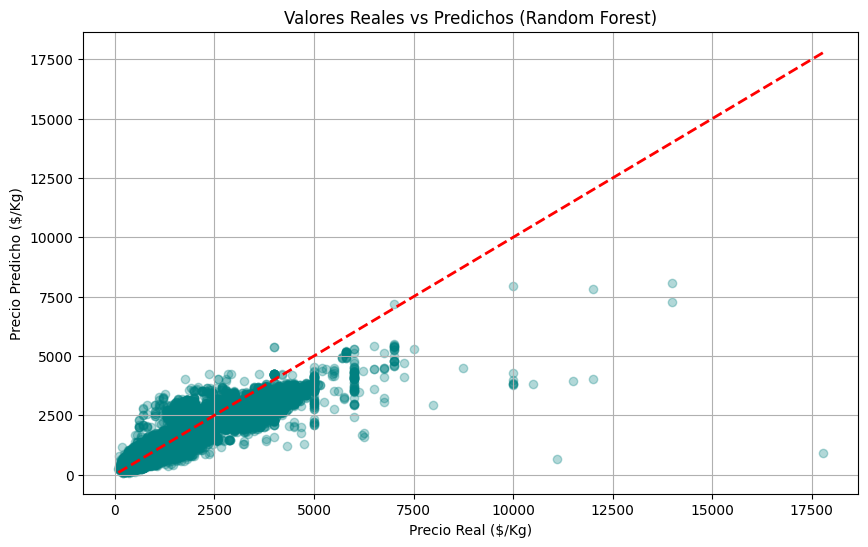

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color="teal")
plt.xlabel("Precio Real ($/Kg)")
plt.ylabel("Precio Predicho ($/Kg)")
plt.title("Valores Reales vs Predichos (Random Forest)")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    lw=2
)
plt.grid(True)
plt.show()

# Análisis de Importancia de Variables

--- Top 15 Variables Más Importantes ---
                                       Variable  Importancia
7                            cat_alta__Producto     0.667051
13                                     num__Mes     0.071730
8                     cat_alta__Variedad / Tipo     0.053532
6                             cat_alta__Mercado     0.041345
9                             cat_alta__Calidad     0.037927
12                               num__weight_kg     0.031526
10                             cat_alta__Origen     0.030888
11                          num__Volumen_Limpio     0.016938
5                     cat_baja__Estacion_Verano     0.015807
2                   cat_baja__Estacion_Invierno     0.011373
4                  cat_baja__Estacion_Primavera     0.010633
3                      cat_baja__Estacion_Otoño     0.004344
14                              num__Dia_Semana     0.003119
1   cat_baja__Subsector_Hortalizas y tubérculos     0.002175
0                    cat_baja__Subsector_Fru

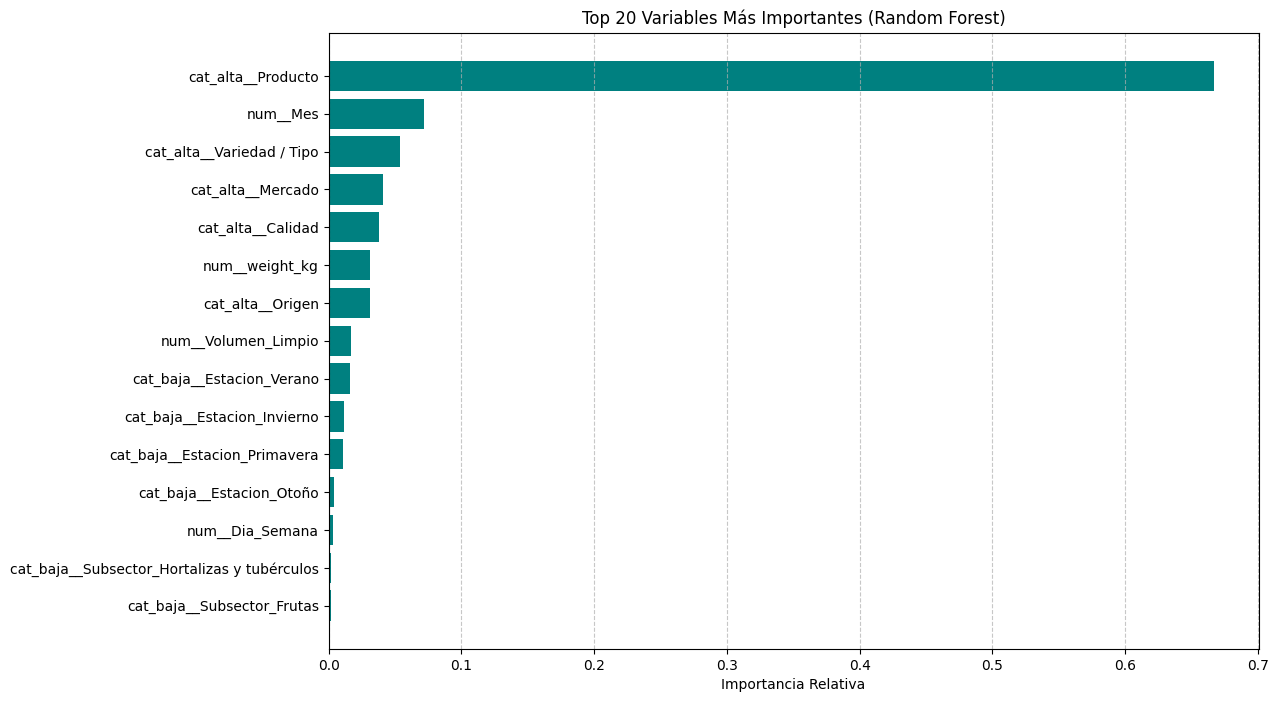

In [13]:
# Recuperamos nombres de variables tras el preprocesador
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = pipeline.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "Variable": feature_names,
    "Importancia": importances
}).sort_values(by="Importancia", ascending=False)

print("--- Top 15 Variables Más Importantes ---")
print(importance_df.head(15))

# Graficar importancia de variables
top20 = importance_df.head(20)
plt.figure(figsize=(12, 8))
plt.barh(top20["Variable"], top20["Importancia"], color="teal")
plt.title("Top 20 Variables Más Importantes (Random Forest)")
plt.gca().invert_yaxis()
plt.xlabel("Importancia Relativa")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()